© [Mariia Seleznova](https://www.ai.math.uni-muenchen.de/members/postdocs/mariia-seleznova/index.html), 2026. [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).

# 🌸  "Hello World” of Data Science: The Iris Dataset

A typical Machine Learning (ML) pipeline includes the following steps:

1. **Load the data** 📥\
First, we load the data (for example, from the internet or from local files) and convert it into a format suitable for analysis.

2. **Explore and visualize** 🔍\
Before training a model, it is often useful to inspect and visualize the data to get an initial sense of its structure, patterns, and potential issues.

3. **Train (or learn) a model** 🧠\
Next, we choose an ML model that fits the task and train it on the data.

4. **Evaluate the model** ✅\
Finally, we check how well the model performs using appropriate evaluation metrics, such as accuracy.

We will walk through these steps using the well-known **Iris dataset**. Just like a “Hello World” program is a classic first example in programming, the Iris dataset provides a classic first example in machine learning.

> "The Iris flower data set or Fisher's Iris data set is a **multivariate data set** introduced by the British statistician and biologist Ronald Fisher in his 1936 paper *The use of multiple measurements in taxonomic problems* as an example of linear discriminant analysis. The data set consists of **50 samples** from each of **three species of Iris (Iris setosa, Iris virginica and Iris versicolor)**. **Four features** were measured from each sample: the length and the width of the sepals and petals, in centimeters. Based on the combination of these four features, Fisher developed a **linear discriminant model to distinguish the species from each other**."  
> — [Wikipedia](https://en.wikipedia.org/wiki/Iris_flower_data_set)

<img src="https://upload.wikimedia.org/wikipedia/commons/5/56/Kosaciec_szczecinkowaty_Iris_setosa.jpg" alt="Iris setosa" width="200"/> <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/9/9f/Iris_virginica.jpg/1920px-Iris_virginica.jpg" alt="Iris virginica" width="325"/> <img src="https://upload.wikimedia.org/wikipedia/commons/4/41/Iris_versicolor_3.jpg" alt="Iris versicolor" width="355"/>

## 📥 Step 1: Load the Iris Dataset

The first step in any ML pipeline is to load the data. Here, we load the Iris dataset directly from a URL using a Pandas library function.

For now, the goal is simply to see a first practical example, without going into all the details. Later in the course, we will learn much more about Python libraries, what they can do, and how to use them.

In [3]:
import sys

print(sys.executable)

c:\Users\Public\anaconda3\envs\applied_ml-course\python.exe


In [4]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
names = ['sepal length [cm]', 'sepal width [cm]', 'petal length [cm]', 'petal width [cm]', 'iris type']
df = pd.read_csv(url, names=names)

Now let us take a quick look at the data.

In [5]:
import sys
print(sys.executable)

!{sys.executable} -m pip show scikit-learn

c:\Users\Public\anaconda3\envs\applied_ml-course\python.exe
Name: scikit-learn
Version: 1.7.2
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License-Expression: BSD-3-Clause
Location: c:\users\public\anaconda3\envs\applied_ml-course\lib\site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: 


In [6]:
df

,sepal length [cm],sepal width [cm],petal length [cm],petal width [cm],iris type
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


Since all features are quantitative (numerical), we do not need any additional preprocessing here. The labels, however, are given as strings, so we will add a new column in which they are represented by integer values to make them easier to work with.

In [7]:
df["class"] = df["iris type"].map({
    "Iris-setosa": 1,
    "Iris-versicolor": 2,
    "Iris-virginica": 3
})

## 🔍 Step 2: Explore and Visualize

It is often useful to visualize your data or the output of your models in order to gain insight. For real-world high-dimensional datasets, visualization can be a challenge in its own right and may require advanced dimensionality reduction techniques. 

But for our Iris example, we will simply plot a 2D projection of the data as points $(x_1, x_2) \in \mathbb{R}^2$, where:
- $x_1$ is the sepal length in cm (the first feature in the data table),
- $x_2$ is the petal width in cm (the fourth feature in the data table).

Text(0, 0.5, 'petal width [cm]')

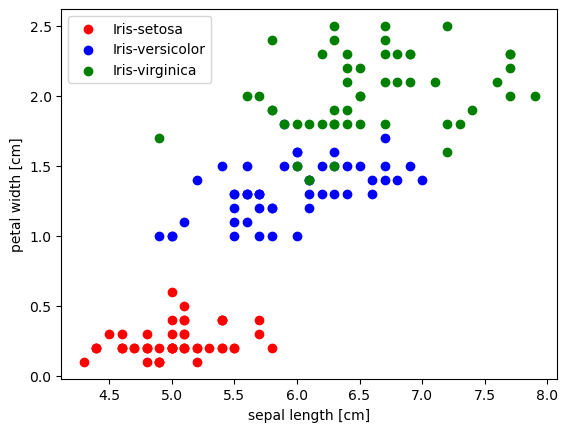

In [8]:
import matplotlib.pyplot as plt

for iris_type, color in zip(
    ["Iris-setosa", "Iris-versicolor", "Iris-virginica"],
    ["red", "blue", "green"]
):
    df_class = df[df["iris type"] == iris_type]
    plt.scatter(
        df_class["sepal length [cm]"],
        df_class["petal width [cm]"],
        c=color,
        label=iris_type
    )

plt.legend()
plt.xlabel("sepal length [cm]")
plt.ylabel("petal width [cm]")

## 🧠 Step 3: Train (or Learn) a Model

A central part of any ML pipeline is choosing an appropriate **ML model** together with a suitable **learning algorithm**, depending on the goal of the analysis and the properties of the data. Exploring a variety of classical ML settings and their corresponding models is one of the main goals of this course.

In the Iris dataset example, we have the following:

- **Analysis goal:** classify irises into three species.
- **Data type:** a multivariate dataset (that is, a table of numbers) with quantitative features and qualitative labels (`Iris-setosa`, `Iris-versicolor`, `Iris-virginica`).

Given this, we are dealing with a problem of **multiclass classification on multivariate (tabular) data**, and we will explore several ML models suitable for this setting.

### ✂️ Train-Test Split

Usually, ML models are trained only on a part of the dataset, called the **training split**, while the rest of the data — called the **test split** — is reserved for evaluation. Here, we split the dataset into training and test parts, leaving 30% of the samples for testing.

For simplicity of visualization, we will continue working with only two of the four features in the dataset.

In [9]:
import sys
!{sys.executable} -m pip install scikit-learn

In [10]:
import numpy as np

from sklearn.model_selection import train_test_split

X = df[["sepal length [cm]", "petal width [cm]"]].to_numpy()
Y = df["class"].to_numpy()

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3
)

print(f"Train split size: {X_train.shape[0]}")
print(f"Test split size: {X_test.shape[0]}")

Train split size: 105
Test split size: 45


We also visualize the results of our train-test split below.

Text(0, 0.5, 'petal width [cm]')

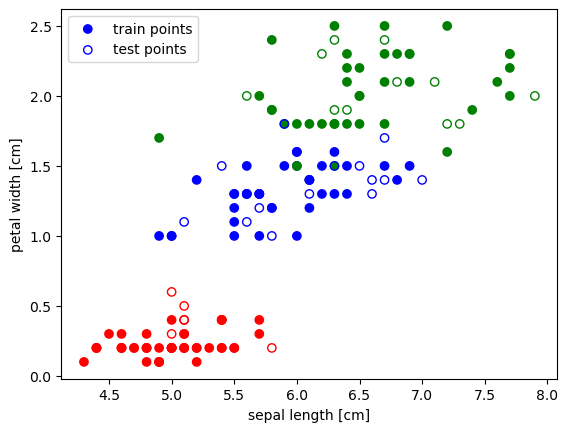

In [11]:
train_colors = np.select([Y_train==1, Y_train==2, Y_train==3],['red', 'blue', 'green'],'n/a')
plt.scatter(X_train[:, 0], X_train[:, 1], c=train_colors,label='train points')

test_colors = np.select([Y_test==1, Y_test==2, Y_test==3],['red', 'blue', 'green'],'n/a')
plt.scatter(X_test[:, 0], X_test[:, 1], edgecolors=test_colors, facecolors='none', label='test points')

plt.legend()
plt.xlabel('sepal length [cm]')
plt.ylabel('petal width [cm]')

We are now ready to train ML models on the training data. 

### 📐 Example 1: Least-Squares Regression

At the core of many ML methods is an **optimization problem**. The idea is: we choose a model with some adjustable parameters, and then try to find parameter values that make the model fit the given data as well as possible. To make this precise, we define a **loss function** $\mathcal{L}$ that measures how well the model matches the data. Training the model then means finding parameter values that minimize this loss.

Our first example, the **least-squares regression** model, solves the following optimization problem:

$$
\min_w \mathcal{L}(X, Y, w) = \min_w \|Xw - Y\|_2^2,
$$

where $X$ is a matrix containing the features of the dataset and $Y$ is a vector of labels. In our case, $X \in \mathbb{R}^{105 \times 2}$ and $Y \in \{1,2,3\}^{105}$, since the training set contains 105 samples and we are working with two numerical features. The optimal parameter vector $w^*\in\mathbb{R}^2$ specifies the learned model.

In this example, we do not implement the model from scratch, but instead use an existing implementation from the `scikit-learn` package. Later in the course, we will implement models ourselves in order to gain more insight into the challenges and design choices involved in setting up ML pipelines.

In [12]:
from sklearn.linear_model import RidgeClassifier

lin_reg = RidgeClassifier(alpha=0).fit(X_train, Y_train)

After training the model, we visualize its results.

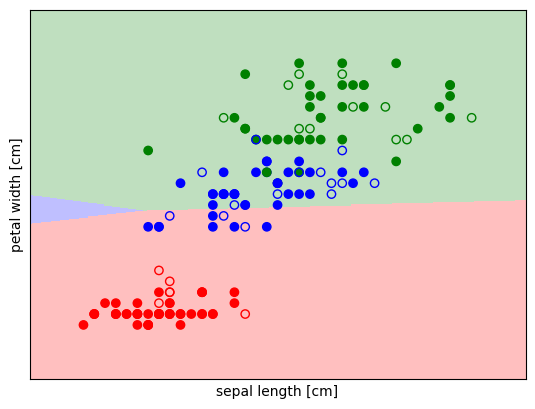

In [13]:
import matplotlib

# Create a fine grid covering the feature space
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
h = 0.01

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

# Predict the class at each grid point
Z = lin_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the predicted regions
cmap = matplotlib.colors.ListedColormap(["red", "blue", "green"])
plt.pcolormesh(xx, yy, Z, alpha=0.25, cmap=cmap)

# Plot training and test points
plt.scatter(X_train[:, 0], X_train[:, 1], c=train_colors)
plt.scatter(X_test[:, 0], X_test[:, 1], edgecolors=test_colors, facecolors="none")

plt.xlabel("sepal length [cm]")
plt.ylabel("petal width [cm]")

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xticks(())
plt.yticks(())

plt.show()

Not very convincing!

### 📈 Example 2: Logistic Regression

We can now try a different linear model: **logistic regression**. As in the previous example, training the model means solving an optimization problem. The difference is that we now use a different loss function.

For logistic regression, the model parameters are chosen by minimizing the following loss:

$$
\min_w \mathcal{L}(X, Y, w) = \min_w \sum_{i=1}^n \log\!\left( \exp(-y_i X_i^T w) + 1 \right).
$$

Here, $X_i\in\mathbb{R}^2$ denotes the feature vector of the $i$-th sample, $y_i\in\mathbb{R}$ is its label, and $w\in\mathbb{R}^2$ is the parameter vector we want to learn. 

In [14]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(penalty=None,fit_intercept=False).fit(X_train, Y_train)

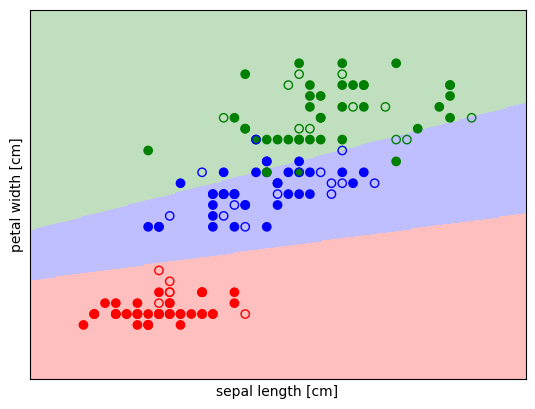

In [15]:
# Predict the class on each point of the grid
Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision regions
cmap = matplotlib.colors.ListedColormap(["red", "blue", "green"])
plt.pcolormesh(xx, yy, Z, alpha=0.25, cmap=cmap)

# Plot the training and test points
plt.scatter(X_train[:, 0], X_train[:, 1], c=train_colors)
plt.scatter(X_test[:, 0], X_test[:, 1], edgecolors=test_colors, facecolors="none")

plt.xlabel("sepal length [cm]")
plt.ylabel("petal width [cm]")

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xticks(())
plt.yticks(())

plt.show()

Much better!

### 🌐 Example 3: SVM with RBF Kernel

Clearly, the data is not linearly separable, so we cannot expect a perfect solution from a linear model. To achieve a better fit, we can therefore try a **nonlinear model**, namely a **Support Vector Machine (SVM)** with an RBF kernel (we will learn what this means later in the course).

In [16]:
from sklearn import svm

rbf_svm = svm.SVC(kernel='rbf', gamma=10, C=1.0).fit(X_train, Y_train)

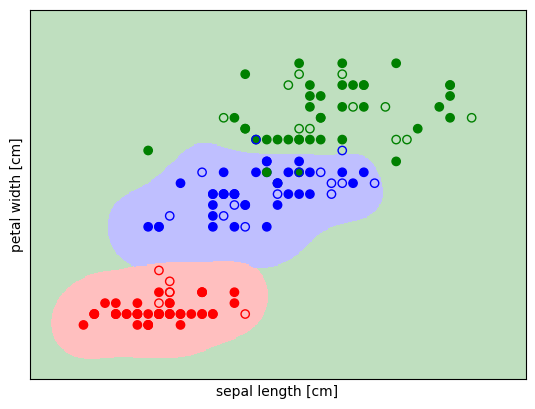

In [17]:
# Predict the class on each point of the grid
Z = rbf_svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision regions
cmap = matplotlib.colors.ListedColormap(["red", "blue", "green"])
plt.pcolormesh(xx, yy, Z, alpha=0.25, cmap=cmap)

# Plot the training and test points
plt.scatter(X_train[:, 0], X_train[:, 1], c=train_colors)
plt.scatter(X_test[:, 0], X_test[:, 1], edgecolors=test_colors, facecolors="none")

plt.xlabel("sepal length [cm]")
plt.ylabel("petal width [cm]")

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xticks(())
plt.yticks(())

plt.show()

Maybe?

## ✅ Step 4: Evaluate the Models

We have seen how the different models perform through visualization. We also want to evaluate their performance numerically using suitable metrics. For classification problems, one of the standard metrics is **accuracy**.

In [18]:
print('Linear regression:')
print('   Train accuracy: ', lin_reg.score(X_train,Y_train))
print('   Test accuracy: ', lin_reg.score(X_test,Y_test))
print()

print('Logistic regression:')
print('   Train accuracy: ', log_reg.score(X_train,Y_train))
print('   Test accuracy: ', log_reg.score(X_test,Y_test))
print()

print('RBF SVM:')
print('   Train accuracy: ', rbf_svm.score(X_train,Y_train))
print('   Test accuracy: ', rbf_svm.score(X_test,Y_test))

Linear regression:
   Train accuracy:  0.7047619047619048
   Test accuracy:  0.5777777777777777

Logistic regression:
   Train accuracy:  0.9333333333333333
   Test accuracy:  0.8666666666666667

RBF SVM:
   Train accuracy:  0.9714285714285714
   Test accuracy:  0.9555555555555556
